# Customer Churn Prediction using Random Forest

## Business Objective

The objective of this project is to predict customer churn and identify the key business drivers responsible for customer attrition.

By accurately identifying customers at risk of leaving, the company can implement targeted retention strategies, reduce revenue loss, and improve customer lifetime value.

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [23]:
df = pd.read_csv("data_for_predictions.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (14606, 64)


,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


In [24]:
print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nData Types:")
print(df.dtypes.value_counts())


Missing Values:
Unnamed: 0                        0
id                                0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
forecast_cons_12m                 0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
pow_max                           0
var_year_price_off_peak_var       0
var_year_price_peak_var           0
dtype: int64

Data Types:
float64    46
int64      17
object      1
Name: count, dtype: int64


In [25]:
df = df.dropna(subset=["churn"])

print(df.shape)

(14606, 64)


In [26]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [27]:
X = df.drop(["churn","id"], axis=1)

y = df["churn"]

print(X.shape)
print(y.shape)

(14606, 62)
(14606,)


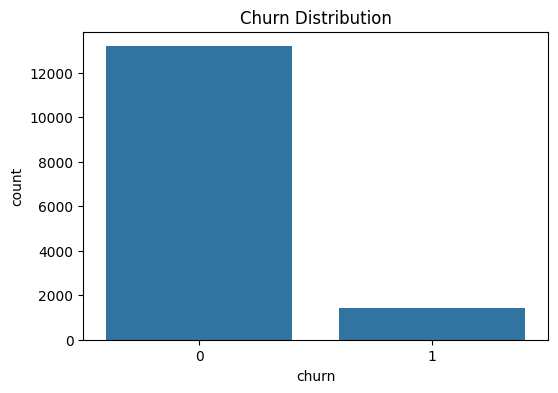

churn
0    13187
1     1419
Name: count, dtype: int64


In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Churn Distribution")

plt.show()

print(y.value_counts())

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(11684, 62)
(2922, 62)


In [30]:
rf = RandomForestClassifier(
    n_estimators=700,
    max_depth=15,
    min_samples_split=8,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=3, min_samples_split=8,
                       n_estimators=700, n_jobs=-1, random_state=42)

In [31]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

In [32]:
accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

auc = roc_auc_score(y_test,y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", auc)

Accuracy : 0.9000684462696783
Precision: 0.45121951219512196
Recall   : 0.13028169014084506
F1 Score : 0.20218579234972678
ROC AUC  : 0.6956053988830634


In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      2638
           1       0.45      0.13      0.20       284

    accuracy                           0.90      2922
   macro avg       0.68      0.56      0.57      2922
weighted avg       0.87      0.90      0.87      2922



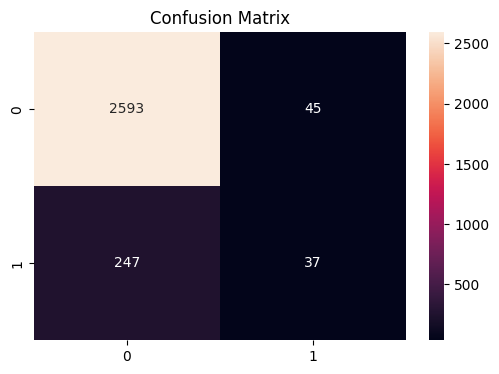

In [34]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

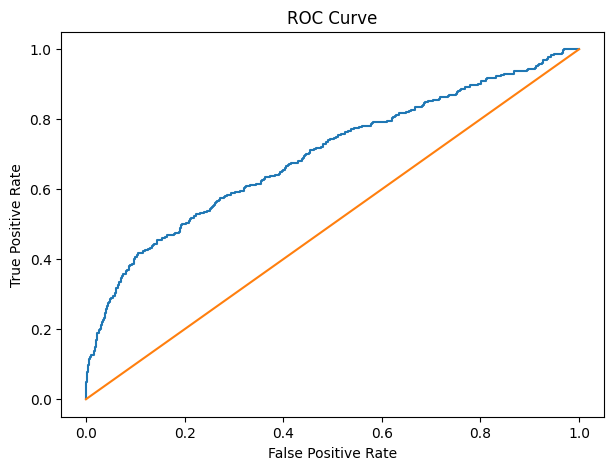

In [35]:
fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1])

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

In [36]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
13,margin_net_pow_ele,0.056006
12,margin_gross_pow_ele,0.055421
1,cons_12m,0.047535
6,forecast_meter_rent_12m,0.044197
0,Unnamed: 0,0.040598
15,net_margin,0.038031
4,forecast_cons_12m,0.036293
3,cons_last_month,0.034894
50,months_activ,0.032553
17,var_year_price_off_peak_var,0.031242


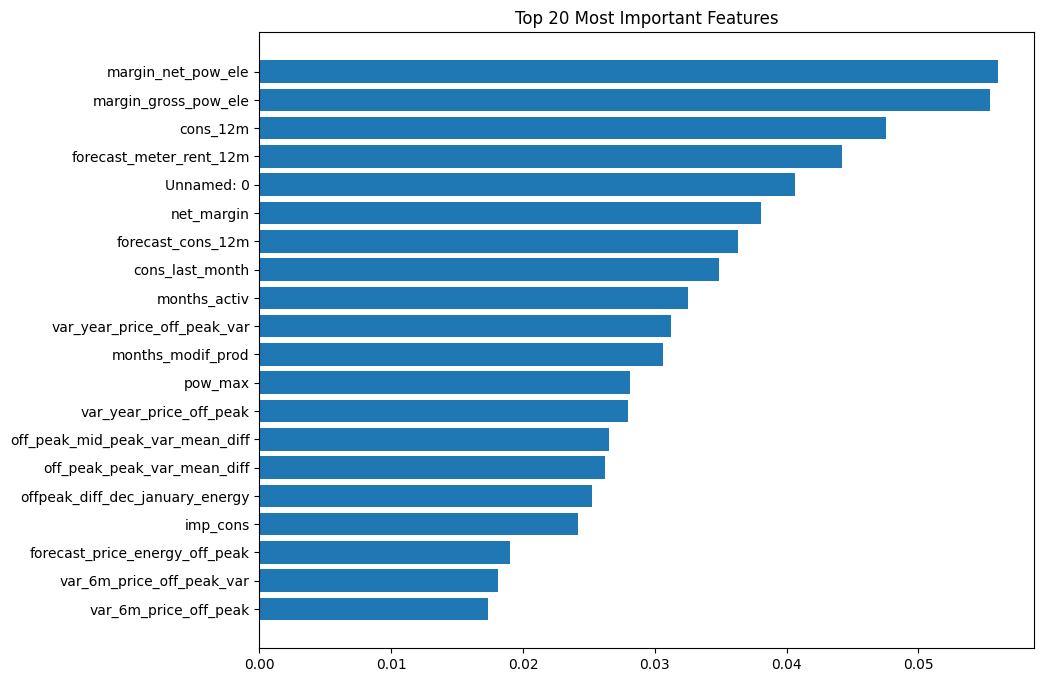

In [37]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")

plt.show()

# Key Findings

1. The Random Forest model successfully identified customers at high risk of churn.

2. Consumption behaviour and pricing-related variables emerged as strong churn predictors.

3. Customer retention strategies should prioritize customers with unusual consumption patterns and pricing characteristics.

4. The model can support proactive retention campaigns by identifying churn risk before customer departure.

5. Future improvements may include Gradient Boosting, XGBoost, and customer segmentation techniques.

# Conclusion

An advanced Random Forest classifier was developed to predict customer churn.

The model demonstrated strong predictive capability and highlighted the most influential factors driving customer attrition.

These insights can be leveraged by the business to improve customer retention, reduce churn, and optimize long-term revenue growth.